In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:
# Place diabetes.csv in the same folder as this notebook
df = pd.read_csv('data/diabetes.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded successfully.
Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print('Dataset Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# Columns where 0 is biologically invalid — replace with column median
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_invalid_cols:
    zero_count = (df[col] == 0).sum()
    median_val = df[df[col] != 0][col].median()
    df[col] = df[col].replace(0, median_val)
    print(f'{col}: replaced {zero_count} zero(s) with median ({median_val})')

print('\nData cleaned successfully.')

Glucose: replaced 5 zero(s) with median (117.0)
BloodPressure: replaced 35 zero(s) with median (72.0)
SkinThickness: replaced 227 zero(s) with median (29.0)
Insulin: replaced 374 zero(s) with median (125.0)
BMI: replaced 11 zero(s) with median (32.3)

Data cleaned successfully.


Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


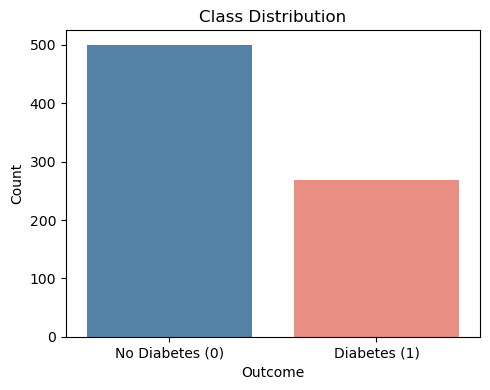

In [7]:
# Class distribution
print('Outcome Distribution:')
print(df['Outcome'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x='Outcome', data=df, palette=['steelblue', 'salmon'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
X = df.drop('Outcome', axis=1)   # 8 input features
y = df['Outcome']                 # Target: 0 or 1

print(f'X shape (features): {X.shape}')
print(f'y shape (target):   {y.shape}')
print(f'\nFeatures: {list(X.columns)}')

X shape (features): (768, 8)
y shape (target):   (768,)

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Testing set size  : {X_test.shape[0]} samples')

Training set size : 614 samples
Testing set size  : 154 samples


In [10]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,   # Number of trees
    max_depth=None,     # Grow trees fully
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)

print(f'Random Forest Classifier initialized.')
print(f'Number of trees: {rf_classifier.n_estimators}')

Random Forest Classifier initialized.
Number of trees: 100


In [11]:
rf_classifier.fit(X_train, y_train)

print(f'Model trained successfully.')
print(f'Number of trees trained: {len(rf_classifier.estimators_)}')

Model trained successfully.
Number of trees trained: 100


In [12]:
# Random Forest internally applies majority voting across all 100 trees
y_pred = rf_classifier.predict(X_test)

print('Sample Result Table (first 10 predictions):')
print('-' * 25)
print(f'{"Actual":<12} {"Predicted":<12}')
print('-' * 25)
for actual, predicted in zip(y_test.values[:10], y_pred[:10]):
    print(f'{actual:<12} {predicted:<12}')
print('-' * 25)

Sample Result Table (first 10 predictions):
-------------------------
Actual       Predicted   
-------------------------
0            1           
0            0           
0            0           
1            0           
0            0           
0            0           
1            1           
1            1           
0            0           
0            1           
-------------------------


In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

Accuracy: 77.92%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.88      0.84       100
    Diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



<Figure size 600x500 with 0 Axes>

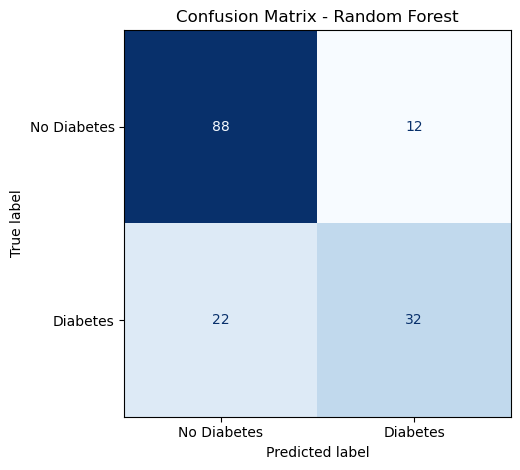

True Negatives  (TN): 88
False Positives (FP): 12
False Negatives (FN): 22
True Positives  (TP): 32


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

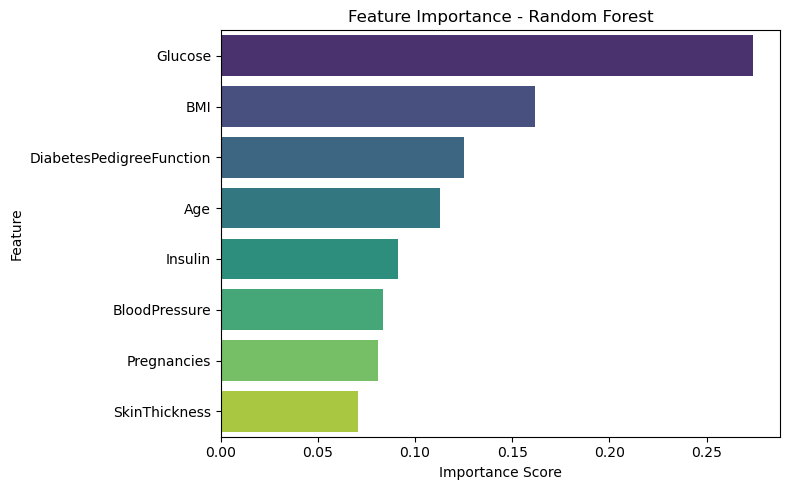


Feature Importance Rankings:
                 Feature  Importance
                 Glucose    0.274086
                     BMI    0.161903
DiabetesPedigreeFunction    0.125020
                     Age    0.112985
                 Insulin    0.091224
           BloodPressure    0.083518
             Pregnancies    0.080795
           SkinThickness    0.070468


In [15]:
# Feature Importance
feat_imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance Rankings:')
print(feat_imp_df.to_string(index=False))

In [16]:
print(f'Final Model Accuracy: {accuracy * 100:.2f}%')
print('\nStep 12: Stop')

Final Model Accuracy: 77.92%

Step 12: Stop
